# Iterative LLM Workflow
### -- Social Tweet Evaluation --

In [27]:
# libraries
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langchain_groq.chat_models import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict, Literal
from dotenv import load_dotenv
import os

In [28]:
# load api key
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [29]:
# load LLM models
generator_llm = ChatGroq(model = "llama-3.3-70b-versatile")
evaluator_llm = ChatGroq(model = "openai/gpt-oss-120b")
optimizer_llm = ChatGroq(model = "llama-3.3-70b-versatile")

In [30]:
# define state
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

In [31]:
# define schema for evaluation
class EvaluationSchema(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(description = "Detailed evaluation of the tweet")
    feedback: str = Field(description = "One paragraph explaining the strenghts and weaknesses of the tweet")

In [32]:
# function
def generate_tweet(state: TweetState):
    messages = [
        SystemMessage(content = "You are a funny and clever Twitter/X influencer."),
        HumanMessage(content = f"""Write a short, witty, and funny tweet for "{state['topic']}"(under 280 characters) with a playful tone. It should feel casual and relatable, like something a meme-loving friend would post. Avoid hashtags, avoid emojis, keep it punchy and scroll-stopping. Also, use simple day to day English. This is version {state['iteration']} + 1""")
    ]
    response = generator_llm.invoke(messages).content

    return {"tweet": response}

In [33]:
# define function
def evaluate_tweet(state: TweetState):
    messages = [
        SystemMessage(content = "You are a witty social media content evaluator."),
        HumanMessage(content = f"""Evaluate the following tweet: "{state['tweet']}" on the basis of Humor, Clarity and Engagement Potential. 
        Respond only in structured format: evaluation -
        - evaluation: "approved" or "needs_improvement" 
        - feedback: one paragraph explaining the strenghts and weaknesses             
        """)
    ]
    structured_eval_model = evaluator_llm.with_structured_output(EvaluationSchema)
    response = structured_eval_model.invoke(messages)

    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback
    }

In [34]:
# define function
def optimize_tweet(state: TweetState):
    messages = [
        SystemMessage(content = "You are a tweet optimization assistant."),
        HumanMessage(content = """
        Your job is to take a given tweet and rewrite it in a way that:
        - Tone → Keep it witty, punchy, and casual (like a funny X user).
        - Length → Must stay under 280 characters.
        - Style → Avoid hashtags and emojis unless they add humor.
        - Goal → Maximize humor, clarity, and engagement while keeping the original idea intact.
        - Output → Provide 2–3 optimized tweet variations. Each should feel natural, not forced.
    """)
    ]
    response = optimizer_llm.invoke(messages).content
    iteration = state["iteration"] + 1

    return {
        "tweet": response, 
        "iteration": iteration    
    }

In [35]:
def route_evaluation(state: TweetState):
    if state["evaluation"] == "approved" or state["iteration"] >= state["max_iteration"]:
        return "approved"
    else:
        return "needs_improvements"

In [36]:
# build graph
graph = StateGraph(TweetState)

# nodes
graph.add_node("generate_tweet", generate_tweet)
graph.add_node("evaluate_tweet", evaluate_tweet)
graph.add_node("optimize_tweet", optimize_tweet)

# edges
graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet", "evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet", route_evaluation, {"approved": END, "needs_improvement": "optimize_tweet"} )
graph.add_edge("optimize_tweet", "evaluate_tweet")

# compile
workflow = graph.compile()

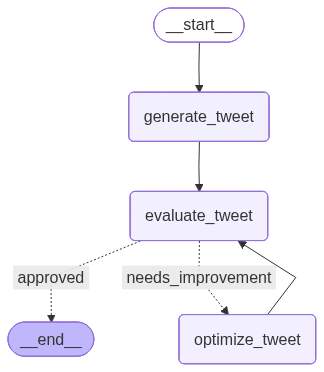

In [37]:
workflow

In [38]:
# execute state
initial_state = {
    "topic": "AI in India",
    "iteration": 1,
    "max_iteration": 5
}
workflow.invoke(initial_state)

{'topic': 'AI in India',
 'tweet': '"AI in India is like my aunt, always trying to predict my marriage and job prospects"',
 'evaluation': 'approved',
 'feedback': 'The tweet scores high on humor by using a relatable cultural analogy that likens AI to a nosy aunt, which is both witty and instantly understandable. Its clarity is solid; the comparison is concise and the imagery is clear, making the joke easy to grasp at a glance. In terms of engagement potential, the blend of tech (AI) and everyday family dynamics invites replies, retweets, and personal anecdotes, especially from Indian audiences who can identify with the aunt trope. However, it could be slightly refined to avoid any unintended offense by ensuring the aunt reference remains light-hearted, and adding a subtle call-to-action (e.g., a question) could boost interaction further.',
 'iteration': 1,
 'max_iteration': 5}